# Notebook 02: Exploratory Data Analysis (EDA)

## Deskripsi
Tujuan dari notebook ini adalah untuk memahami karakteristik data, menemukan pola tersembunyi, dan mendeteksi anomali sebelum masuk ke tahap pembuatan model.

## Alur Kerja (Workflow)
1. **Descriptive Statistics**: Melihat ringkasan data (mean, median, standar deviasi) untuk memahami sebaran nilai.
2. **Univariate Analysis**: Menganalisis satu per satu kolom (menggunakan histogram atau boxplot) untuk melihat *outliers*.
3. **Multivariate Analysis**: Melihat hubungan antar kolom (korelasi) menggunakan *heatmap*.
4. **Feature Target Relation**: Menganalisis bagaimana hubungan fitur-fitur yang ada terhadap target yang ingin diprediksi.

## Kesimpulan
Kita telah mendapatkan *insight* mengenai fitur mana saja yang berpengaruh kuat terhadap target. Hasil observasi di sini akan menjadi dasar bagi kita dalam melakukan *Feature Engineering* di tahap berikutnya.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import sys

# 1. Mantra sakti akses folder src
parent_dir = os.path.abspath("..")
src_path = os.path.join(parent_dir, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

import utils

# 2. Muat konfigurasi
config = utils.load_config("../config/config.yaml")

# 3. Load Data Interim (Pake nama file dari config agar sinkron!)
path_interim = os.path.join("..", config['paths']['interim_dataset_dir'], config['paths']['interim_filename'])
df = joblib.load(path_interim)

print(f"Berhasil memuat data: {path_interim}")
print(f"Dimensi Awal: {df.shape[0]} baris x {df.shape[1]} kolom")
df.head()

Berhasil memuat data: ../data/interim/data_gabungan.pkl
Dimensi Awal: 1675 baris x 11 kolom


,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,category
0,2021-01-01,DKI1 (Bunderan HI),38.0,53.0,29.0,6.0,31.0,13.0,53,PM25,SEDANG
1,2021-01-02,DKI1 (Bunderan HI),27.0,46.0,27.0,7.0,47.0,7.0,47,O3,BAIK
2,2021-01-03,DKI1 (Bunderan HI),44.0,58.0,25.0,7.0,40.0,13.0,58,PM25,SEDANG
3,2021-01-04,DKI1 (Bunderan HI),30.0,48.0,24.0,4.0,32.0,7.0,48,PM25,BAIK
4,2021-01-05,DKI1 (Bunderan HI),38.0,53.0,24.0,6.0,31.0,9.0,53,PM25,SEDANG


In [2]:
def audit_waktu_data(df_input):
    """
    Melakukan konversi tanggal dengan mencoba berbagai format agar data tidak hilang,
    serta memberikan laporan ketersediaan data per bulan.

    Parameters:
    -----------
    df_input : pandas.DataFrame
        Dataframe mentah yang kolom tanggalnya masih bermasalah.

    Returns:
    --------
    df_clean : pandas.DataFrame
        Dataframe yang sudah bersih dengan tambahan kolom tahun dan bulan.
    """
    df_clean = df_input.copy()
    
    # 1. Coba konversi dengan gaya Indonesia (Hari di depan: 31-01-2021)
    df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'], dayfirst=True, errors='coerce')
    
    # 2. Hitung berapa yang gagal
    nat_awal = df_clean['tanggal'].isna().sum()
    
    if nat_awal > 0:
        print(f"INFO: Ada {nat_awal} baris yang gagal dibaca di percobaan pertama. Mencoba format cadangan...")
        # Percobaan kedua: Jika baris tersebut NaT, coba baca dengan gaya standar (Tahun di depan)
        df_clean['tanggal'] = df_clean['tanggal'].fillna(
            pd.to_datetime(df_input['tanggal'], dayfirst=False, errors='coerce')
        )
    
    # 3. Hapus baris yang BENAR-BENAR rusak (misal baris kosong dari file CSV)
    df_clean = df_clean.dropna(subset=['tanggal'])
    
    # 4. Tambahkan informasi waktu
    df_clean['tahun'] = df_clean['tanggal'].dt.year.astype(int)
    df_clean['bulan_angka'] = df_clean['tanggal'].dt.month.astype(int)
    df_clean['nama_bulan'] = df_clean['tanggal'].dt.month_name()
    
    # 5. Laporan Akhir
    print(f"INFO: Pembersihan selesai. Dimensi akhir: {df_clean.shape}")
    print("\n--- Audit Data Per Bulan ---")
    audit = df_clean.groupby(['tahun', 'bulan_angka', 'nama_bulan']).size().reset_index(name='jumlah_hari')
    print(audit.sort_values(['tahun', 'bulan_angka']))
    
    return df_clean

# --- EKSEKUSI ---
df = audit_waktu_data(df)

INFO: Ada 1015 baris yang gagal dibaca di percobaan pertama. Mencoba format cadangan...
INFO: Pembersihan selesai. Dimensi akhir: (1675, 14)

--- Audit Data Per Bulan ---
    tahun  bulan_angka nama_bulan  jumlah_hari
0    2021            1    January          150
1    2021            2   February          135
2    2021            3      March          150
3    2021            4      April          145
4    2021            5        May          150
5    2021            6       June           55
6    2021            7       July          150
7    2021            8     August          150
8    2021            9  September          145
9    2021           10    October          150
10   2021           11   November          145
11   2021           12   December          150


In [3]:
def cek_kesehatan_data(df):
    """
    Fungsi untuk mengecek kondisi data secara menyeluruh sebelum visualisasi.
    Menampilkan info dasar, sampel data, data kosong, dan statistik.
    """
    print("=== LAPORAN KONDISI DATA ===")
    
    # 1. Info struktur dan tipe data
    print(f"\n[1] Total Data: {df.shape[0]} baris & {df.shape[1]} kolom")
    print("-" * 30)
    df.info()
    
    # 2. Lihat contoh data secara acak
    print("\n[2] Contoh 3 baris data (acak):")
    display(df.sample(3))
    
    # 3. Cek data yang masih kosong
    print("\n[3] Cek Data Kosong (Missing Value):")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "Mantap! Tidak ada data kosong.")
    
    # 4. Statistik singkat untuk polutan
    print("\n[4] Ringkasan Angka Polutan:")
    kolom_polutan = config['int_columns']
    display(df[kolom_polutan].describe())

# --- EKSEKUSI ---
cek_kesehatan_data(df)

=== LAPORAN KONDISI DATA ===

[1] Total Data: 1675 baris & 14 kolom
------------------------------
<class 'pandas.DataFrame'>
Index: 1675 entries, 0 to 1829
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   tanggal      1675 non-null   datetime64[us]
 1   stasiun      1675 non-null   str           
 2   pm10         1607 non-null   float64       
 3   pm25         1578 non-null   float64       
 4   so2          1562 non-null   float64       
 5   co           1643 non-null   float64       
 6   o3           1611 non-null   float64       
 7   no2          1640 non-null   float64       
 8   max          1675 non-null   object        
 9   critical     1659 non-null   str           
 10  category     1674 non-null   str           
 11  tahun        1675 non-null   int64         
 12  bulan_angka  1675 non-null   int64         
 13  nama_bulan   1675 non-null   str           
dtypes: datetime64[us](1),

,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,category,tahun,bulan_angka,nama_bulan
412,2021-03-25,DKI4 (Lubang Buaya),36.0,68.0,41.0,8.0,19.0,12.0,68,PM25,SEDANG,2021,3,March
464,2021-04-15,DKI1 (Bunderan HI),56.0,74.0,24.0,24.0,21.0,40.0,74,PM25,SEDANG,2021,4,April
1264,2021-09-15,DKI2 (Kelapa Gading),69.0,95.0,54.0,17.0,45.0,35.0,95,PM25,SEDANG,2021,9,September



[3] Cek Data Kosong (Missing Value):
pm10         68
pm25         97
so2         113
co           32
o3           64
no2          35
critical     16
category      1
dtype: int64

[4] Ringkasan Angka Polutan:


,pm10,pm25,so2,co,o3,no2
count,1607.000000,1578.000000,1562.000000,1643.000000,1611.000000,1640.000000
mean,51.408836,76.843473,34.808579,11.744979,32.006828,18.982317
std,14.776508,23.069143,12.747229,5.078563,14.754490,9.122329
min,14.000000,13.000000,2.000000,2.000000,7.000000,1.000000
25%,42.000000,61.250000,25.000000,9.000000,22.000000,13.000000
50%,53.000000,77.000000,34.000000,11.000000,29.000000,17.000000
75%,61.000000,91.000000,44.000000,14.000000,39.000000,24.000000
max,179.000000,174.000000,82.000000,47.000000,151.000000,65.000000


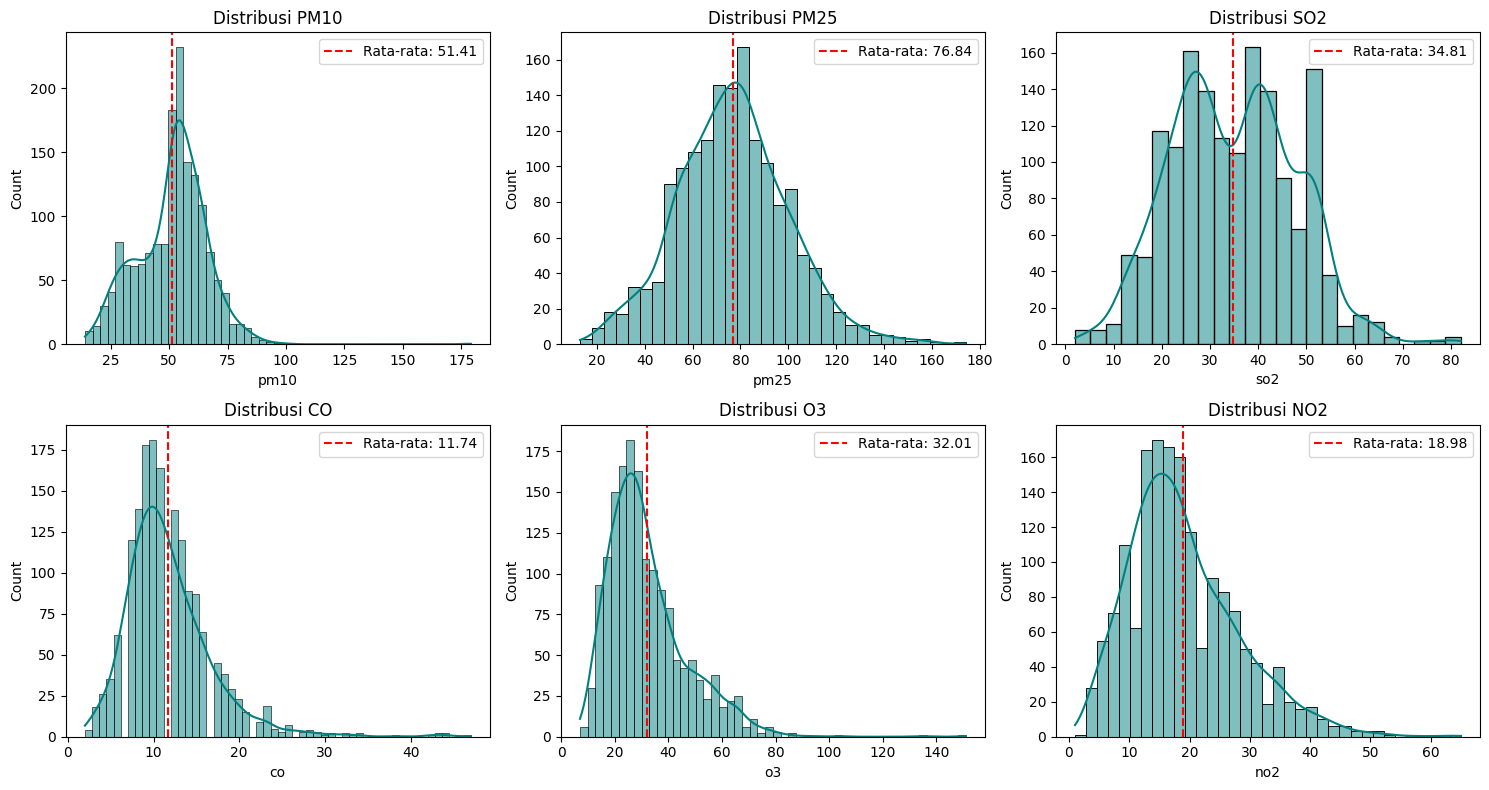

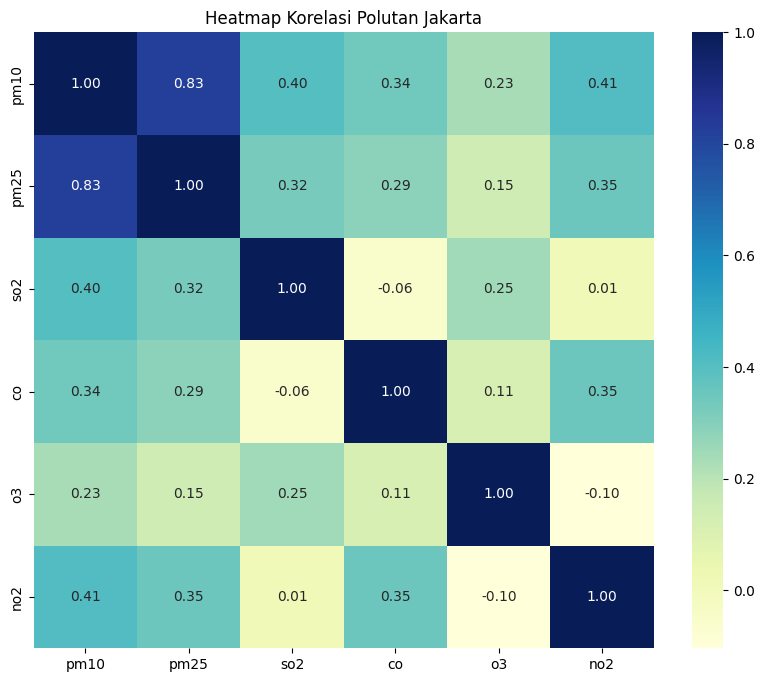

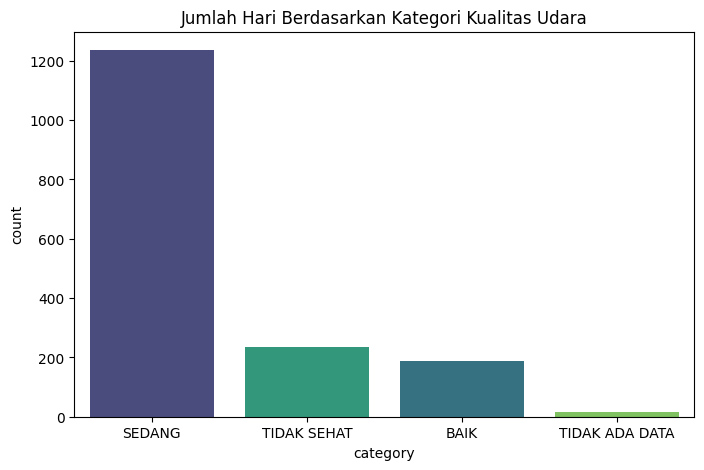

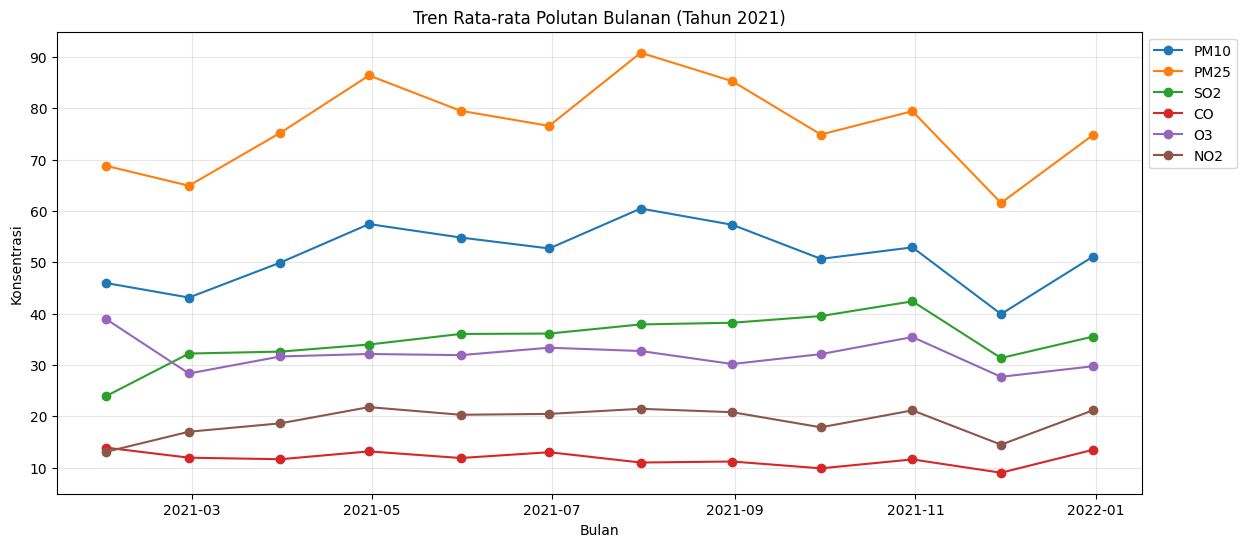

In [4]:
# 1. Fungsi Distribusi Polutan (Histogram)
def plot_distribusi(df, kolom_polutan):
    n_cols = 3
    n_rows = (len(kolom_polutan) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(kolom_polutan):
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
        mean_val = df[col].mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Rata-rata: {mean_val:.2f}')
        axes[i].set_title(f'Distribusi {col.upper()}')
        axes[i].legend()

    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

# 2. Fungsi Korelasi (Heatmap)
def plot_korelasi(df, kolom_polutan):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[kolom_polutan].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
    plt.title("Heatmap Korelasi Polutan Jakarta")
    plt.show()

# 3. Fungsi Kategori Udara (Bar Chart)
def plot_kategori(df, kolom_target):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=kolom_target, hue=kolom_target, palette='viridis', 
                  order=df[kolom_target].value_counts().index, legend=False)
    plt.title("Jumlah Hari Berdasarkan Kategori Kualitas Udara")
    plt.show()

# 4. Fungsi Tren Bulanan (Line Chart)
def plot_tren_bulanan(df, kolom_polutan):
    # Resample bulanan (Data Juni yang cuma 55 baris tetap akan terhitung rata-ratanya)
    df_monthly = df.set_index('tanggal').resample('ME').mean(numeric_only=True)
    
    plt.figure(figsize=(14, 6))
    for col in kolom_polutan:
        plt.plot(df_monthly.index, df_monthly[col], marker='o', label=col.upper())
    
    plt.title("Tren Rata-rata Polutan Bulanan (Tahun 2021)")
    plt.xlabel("Bulan")
    plt.ylabel("Konsentrasi")
    plt.legend(bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EKSEKUSI SEMUA VISUALISASI ---
kolom_polutan = config['int_columns']

plot_distribusi(df, kolom_polutan)
plot_korelasi(df, kolom_polutan)
plot_kategori(df, config['label'])
plot_tren_bulanan(df, kolom_polutan)

In [5]:
def imputasi_eda(df_input, config):
    """
    Mengisi data kosong menggunakan nilai default dari config 
    agar data rapi di akhir tahap EDA.
    """
    df_imputed = df_input.copy()
    kolom_polutan = config['int_columns']
    
    print("--- Proses Imputasi (Sederhana) ---")
    for col in kolom_polutan:
        jml_kosong = df_imputed[col].isnull().sum()
        if jml_kosong > 0:
            # Gunakan rata-rata kolom tersebut untuk mengisi yang kosong
            mean_val = df_imputed[col].mean()
            df_imputed[col] = df_imputed[col].fillna(mean_val)
            print(f"Selesai: {col} ({jml_kosong} data diisi dengan nilai {mean_val:.2f})")
            
    return df_imputed

# Eksekusi
df_final_eda = imputasi_eda(df, config)

# Cek akhir
print(f"\nJumlah missing value sekarang: {df_final_eda.isnull().sum().sum()}")

--- Proses Imputasi (Sederhana) ---
Selesai: pm10 (68 data diisi dengan nilai 51.41)
Selesai: pm25 (97 data diisi dengan nilai 76.84)
Selesai: so2 (113 data diisi dengan nilai 34.81)
Selesai: co (32 data diisi dengan nilai 11.74)
Selesai: o3 (64 data diisi dengan nilai 32.01)
Selesai: no2 (35 data diisi dengan nilai 18.98)

Jumlah missing value sekarang: 17


## Kesimpulan Eksplorasi Data (EDA)

1. **Ketersediaan Data**: Data berhasil dimuat sebanyak 1675 baris. Masalah format tanggal pada bulan Juni telah diatasi dengan metode `fillna` pada konversi datetime.
2. **Kualitas Data**: 
   - Terdapat missing value pada beberapa polutan (terbanyak pada SO2: 50 data).
   - Data ini **TIDAK** dilakukan imputasi di tahap EDA untuk menghindari *data leakage*.
3. **Insight Visualisasi**:
   - PM2.5 memiliki konsentrasi tertinggi dibanding polutan lain, terutama pada bulan Agustus (musim kemarau).
   - Terdapat korelasi positif yang kuat antara PM10 dan PM2.5.
4. **Langkah Selanjutnya**: 
   - Melakukan **Train-Test Split (TTS)** di awal Notebook Preprocessing.
   - Melakukan imputasi menggunakan nilai Mean dari data Train saja.